This Jupyter Notebook is part of a **collection of scripts curated by Tarlan Ahadli** for the **2025 Spring Semester**, based on **projects provided by Prof. Hajder Levente**. These scripts cover a range of computational topics, including **computer vision, image processing, numerical computing, and matrix transformations**, serving as educational resources for academic use.

### **Usage Restrictions**
This material is **strictly for academic and educational purposes**.  
**Commercial use is prohibited.**

For any **issues, suggestions, or inquiries**, please contact:  
📧 **tarlanahad@gmail.com**

# **RANSAC for Line Fitting**
In this notebook, we'll explore the RANSAC (Random Sample Consensus) algorithm for robust line fitting. We'll generate synthetic data with a mixture of **inliers** and **outliers**, then apply the RANSAC procedure to estimate a line that best fits the inliers while rejecting the outliers.

## **Table of Contents**
1. Overview
2. Synthetic Data Generation
3. RANSAC Algorithm
4. Implementation
5. Results
6. Conclusion

---


## 1. Overview
**RANSAC** stands for **Random Sample Consensus**. It is a popular algorithm to robustly fit a model (like a line or plane) when the data contains a large number of outliers.

**Key Steps**:
1. Randomly select a small subset of data to form a model.
2. Determine how many points from the entire dataset fit the model (inliers).
3. Update the best model if the new one has more inliers.
4. Adaptively update the number of iterations needed based on the ratio of inliers found.


## 2. Synthetic Data Generation
For this demonstration, we'll generate a 2D dataset that is partly on a line (inliers) and partly random (outliers).


## Mathematical Explanation of `generate_data(N, p, direction, inlier_ratio)`

This function generates a set of $ N $ two-dimensional points, consisting of:

- **Inlier Points** that lie roughly along a line passing through a reference point $ \mathscr{p} $ in the direction of $ \mathscr{d} $.
- **Outlier Points** scattered randomly within a bounding rectangle $ [0, \text{WIDTH}] \times [0, \text{HEIGHT}] $.

### Step-by-Step Mathematical Breakdown

### 1. Normalize Direction Vector
We normalize the direction vector $ \mathscr{d} $ as:

$$
\mathbf{d} \leftarrow \frac{\mathscr{d}}{\|\mathscr{d}\|}
$$

ensuring that $ \|\mathbf{d}\| = 1 $.

### 2. Partition $ N $ into Inliers and Outliers
Given $\text{inlier_ratio}$, we compute:

$$
\begin{align}
N_{\text{inlier}} &= \lfloor N \times \text{inlier_ratio} \rfloor \\
N_{\text{outlier}} &= N - N_{\text{inlier}}
\end{align}
$$

### 3. Generate Inliers Along a Line
- Define $ \mathscr{p} $ as the base point.
- Select $ t \sim \text{Uniform}(-\frac{\text{diag}}{2}, \frac{\text{diag}}{2}) $, where:

  $$
  \text{diag} = \sqrt{\text{WIDTH}^2 + \text{HEIGHT}^2}.
  $$

- Compute each inlier point:

  $$
  \mathscr{q} = \mathscr{p} + t \mathscr{d}.
  $$

- Add **Gaussian noise** $ \mathscr{N}(0,10) $ to both coordinates.


  $$
  \begin{align}
  \mathscr{q}[0] &\leftarrow \mathscr{q}[0] + \mathscr{N}(0,10) \\
  \mathscr{q}[1] &\leftarrow \mathscr{q}[1] + \mathscr{N}(0,10).
  \end{align}
  $$

### 4. Generate Outliers
For each of the $ N_{\text{outlier}} $ points, sample randomly:

$$
\begin{align}
x &\sim \text{Uniform}(0, \text{WIDTH}) \\
y &\sim \text{Uniform}(0, \text{HEIGHT}).
\end{align}
$$

### 5. Return Combined Array
Finally, we combine both inlier and outlier sets into a single NumPy array $ \mathbb{R}^{N \times 2} $.

### Purpose
This approach simulates a **robust line model** with a specified inlier ratio, useful for testing RANSAC or other robust fitting algorithms under controlled conditions.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

def init_random(seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

def generate_data(N, p, direction, inlier_ratio=0.5):
    WIDTH, HEIGHT = 640, 480
    p = np.array(p, dtype=float)
    direction = np.array(direction, dtype=float)
    direction /= np.linalg.norm(direction)

    N_inlier = int(N * inlier_ratio)
    N_outlier = N - N_inlier

    points = []

    diag = np.sqrt(WIDTH**2 + HEIGHT**2)
    for _ in range(N_inlier):
        t = (random.random() * diag) - diag / 2.0
        q = p + t * direction
        q[0] += np.random.normal(0.0, 10.0)
        q[1] += np.random.normal(0.0, 10.0)
        points.append(q)

    for _ in range(N_outlier):
        points.append((random.random() * WIDTH, random.random() * HEIGHT))

    return np.array(points, dtype=float)


In [2]:
init_random(seed=0)

N = 1000
p = (240.0, 320.0)
alpha = random.random() * 2.0 * np.pi
dir_ = (np.cos(alpha), np.sin(alpha))
points = generate_data(N, p, dir_, inlier_ratio=0.5)

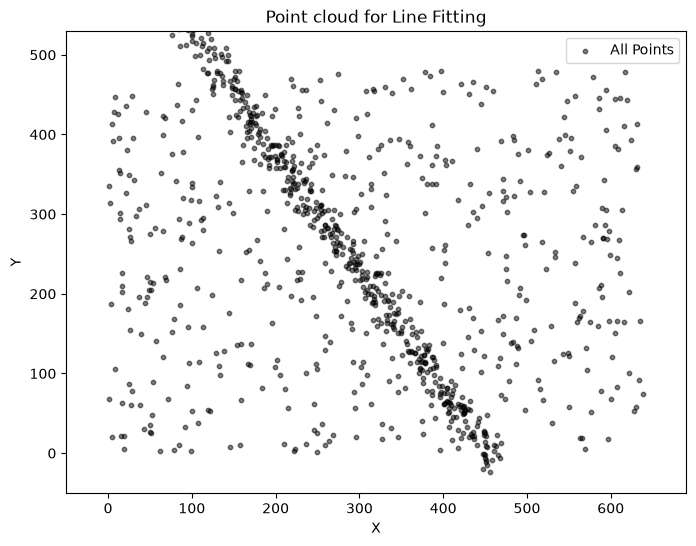

In [3]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(points[:,0], points[:,1], s=10, c='k', alpha=0.5, label='All Points')


ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Point cloud for Line Fitting')
ax.legend()
plt.show()


## 3. RANSAC Algorithm
To robustly fit a line, we perform these steps repeatedly:

1. **Random Sampling**: Pick two distinct points from the dataset.
2. **Model Fitting**: Estimate a line from these two points.
3. **Distance Calculation**: Compute the perpendicular distance to the line.
4. **Counting Inliers**: Determine inliers based on a threshold.
5. **Best Model Update**: Keep the best-fitting model.
6. **Adaptive Iteration**: Adjust iterations based on inlier ratio.


## Mathematical Explanation of `fit_line_two_points(p1, p2)`

This function computes a **normalized line representation** $ a x + b y + c = 0 $ from two distinct points in $ \mathbb{R}^2 $.

### Step-by-Step Mathematical Breakdown

### 1. Define Points and Compute Differences
We are given two points:

$$
\mathscr{p}_1 = (x_1, y_1), \quad \mathscr{p}_2 = (x_2, y_2).
$$

We define the differences:

$$
\Delta x = x_2 - x_1, \quad \Delta y = y_2 - y_1.
$$

The Euclidean distance (norm) between these points is:

$$
\mathscr{d} = \sqrt{(\Delta x)^2 + (\Delta y)^2}.
$$

If $ \mathscr{d} < 10^{-8} $, the points are too close, meaning they are effectively identical and cannot define a unique line.

### 2. Compute Normalized Line Parameters
A line passing through $ \mathscr{p}_1 $ and $ \mathscr{p}_2 $ has a **direction vector** $ (\Delta x, \Delta y) $. A **normal vector** to this line is $ (-\Delta y, \Delta x) $. We define:

$$
 a = \frac{-\Delta y}{\mathscr{d}}, \quad b = \frac{\Delta x}{\mathscr{d}}.
$$

Since we divide by $ \mathscr{d} $, we ensure that $ \sqrt{a^2 + b^2} = 1 $, meaning $ (a, b) $ is a **unit normal vector**.

### 3. Compute Parameter $ c $

We want the line $ a x + b y + c = 0 $ to pass through $ \mathscr{p}_1 = (x_1, y_1) $. Thus:

$$
 c = - (a x_1 + b y_1).
$$

So the final line equation is:

$$
 a x + b y + c = 0,
$$

with $ \sqrt{a^2 + b^2} = 1 $ ensuring normalization.

### 4. Return Value
- **Output**: $ (a, b, c) $ (or `None` if the input points are too close).
- This representation is useful for computing perpendicular distances, fitting algorithms, and other geometric operations.



In [4]:
import math

def fit_line_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    norm = math.sqrt(dx**2 + dy**2)
    if norm < 1e-8:
        return None
    a, b = -dy / norm, dx / norm
    c = -a * x1 - b * y1
    return a, b, c

## Mathematical Explanation of `distance_point_line(line_params, point)`

This function computes the **perpendicular distance** from a point $ \mathscr{p} = (x, y) $ to a line given in the standard form:

$$
 a x + b y + c = 0.
$$

### Step-by-Step Mathematical Breakdown

### 1. Line Parameters and Input Point
We are given:
- A line defined by parameters $ (a, b, c) $, where the equation of the line is:
  $$
  a x + b y + c = 0.
  $$
- A point $ \mathscr{p} = (x, y) $ whose distance to the line we seek to compute.

### 2. Compute the Perpendicular Distance
The **perpendicular (shortest) distance** from a point $ \mathscr{p} $ to the line is given by:

$$
 \mathscr{d} = \frac{| a x + b y + c |}{\sqrt{a^2 + b^2}}.
$$

#### Proof of the Distance Formula
Let $ \mathscr{p}_0 = (x_0, y_0) $ be a point in space, and let the line be given by:

$$
 a x + b y + c = 0.
$$

1. The direction vector of the normal to the line is:
   $$
   \mathbf{n} = (a, b).
   $$
   Since the normal vector is perpendicular to the line, any point $ (x, y) $ on the line satisfies:
   $$
   a x + b y + c = 0.
   $$

2. The projection of the vector from $ \mathscr{p}_0 $ to any point $ \mathscr{p}_1 $ on the line onto the normal vector $ \mathbf{n} $ gives the perpendicular distance:
   $$
   \mathscr{d} = \frac{| \mathbf{n} \cdot \mathbf{p}_0 + c |}{\| \mathbf{n} \|}.
   $$
   Expanding the dot product:
   $$
   \mathscr{d} = \frac{| a x_0 + b y_0 + c |}{\sqrt{a^2 + b^2}}.
   $$

Since $ (x_0, y_0) $ is the point given as input, the formula holds:

$$
 \mathscr{d} = \frac{| a x + b y + c |}{\sqrt{a^2 + b^2}}.
$$

Since the function `distance_point_line` assumes a **normalized line**, meaning $ \sqrt{a^2 + b^2} = 1 $, the denominator cancels out, and the formula simplifies to:

$$
 \mathscr{d} = | a x + b y + c |.
$$

### 3. Return Value
- The function returns the absolute perpendicular distance $ \mathscr{d} $.
- This formula is useful in applications like geometric error measurement, point-line fitting, and distance calculations in computational geometry.



In [5]:
def distance_point_line(line_params, point):
    a, b, c = line_params
    x, y = point
    return abs(a*x + b*y + c)

## Mathematical Explanation of `iteration_number(confidence, sample_size, inliers, N)`

This function computes the **number of RANSAC iterations** required to ensure, with a given confidence level, that at least one randomly selected subset consists entirely of inliers.

### Step-by-Step Mathematical Breakdown

### 1. Key Terms and Definitions
- **Inlier Ratio** \( w \): The fraction of points that are inliers.
- **Sample Size** \( s \): The minimum number of points needed to estimate the model.
- **Confidence** \( p \): The probability that at least one sample contains only inliers.

The probability of picking an inlier at random is:

$$
 w = \frac{\text{inliers}}{N}.
$$

If ( inliers = 0 ), then \( w = 0 \), meaning RANSAC cannot reliably find a correct model. In this case, the function returns \( $\infty$ \) (indicating an unbounded number of iterations might be required).

### 2. Probability of a Good Sample
The probability that a randomly chosen sample of size \( s \) consists **only** of inliers is:

$$
 w^s.
$$

### 3. Probability of All Bad Samples
If we run \( k \) iterations, the probability that **none** of these \( k \) samples contain only inliers is:

$$
 (1 - w^s)^k.
$$

### 4. Confidence Constraint
To ensure a confidence level \( p \), we require:

$$
 (1 - w^s)^k \leq 1 - p.
$$

### 5. Solving for \( k \)
Taking the natural logarithm of both sides:

$$
 k \ln(1 - w^s) \leq \ln(1 - p).
$$

Thus:

$$
 k \geq \frac{\ln(1 - p)}{\ln(1 - w^s)}.
$$

Since RANSAC requires an integer number of iterations, we take the **ceiling**:

$$
 k = \left\lceil \frac{\ln(1 - p)}{\ln(1 - w^s)} \right\rceil.
$$

### 6. Return Value
- If `inliers == 0`, we return \( $\infty$ \) since no inlier-based model can be drawn.
- If the denominator \( $\ln(\dots)$ \) is zero or extremely small, we also return \( $\infty$ \).
- Otherwise, we return the **ceiling** of the above fraction, indicating the required iterations to reach the given confidence level.



In [6]:
def iteration_number(confidence, sample_size, inliers, N):
    if inliers == 0:
        return float('inf')
    ratio = inliers / float(N)
    top = math.log(1.0 - confidence)
    bottom = math.log(1.0 - ratio**sample_size)
    return math.ceil(top / bottom) if bottom != 0 else float('inf')

In [7]:
def ransac_line(points, max_iterations=2000, sigma=10.0, confidence=0.95):
    best_inliers_count = 0
    best_line, best_inliers_list = None, []

    for _ in range(max_iterations):
        idx1, idx2 = np.random.choice(len(points), 2, replace=False)
        line_params = fit_line_two_points(points[idx1], points[idx2])
        if line_params is None:
            continue

        inliers = [pt for pt in points if distance_point_line(line_params, pt) < sigma]

        if len(inliers) > best_inliers_count:
            best_inliers_count, best_line, best_inliers_list = len(inliers), line_params, inliers
            max_iterations = min(max_iterations, iteration_number(confidence, 2, best_inliers_count, len(points)))
            print(max_iterations)


    return best_line, np.array(best_inliers_list)


## 4. Implementation
We'll follow the sequence:

1. **Initialize the random seed** for reproducibility.
2. **Generate synthetic data** of size 1000, with 50% inliers.
3. **Apply RANSAC** to fit a line.
4. **Refine the best line** using all inliers.


In [8]:


best_line, inliers = ransac_line(points)
print(f"Best line: a={best_line[0]:.3f}, b={best_line[1]:.3f}, c={best_line[2]:.3f}")
print(f"Number of inliers: {len(inliers)} out of {len(points)}")


804
532
23
22
22
Best line: a=-0.825, b=-0.565, c=376.600
Number of inliers: 362 out of 1000


## 5. Results
We'll visualize the **inlier** and **outlier** points, and also draw the **true line** and **RANSAC-fitted line**.


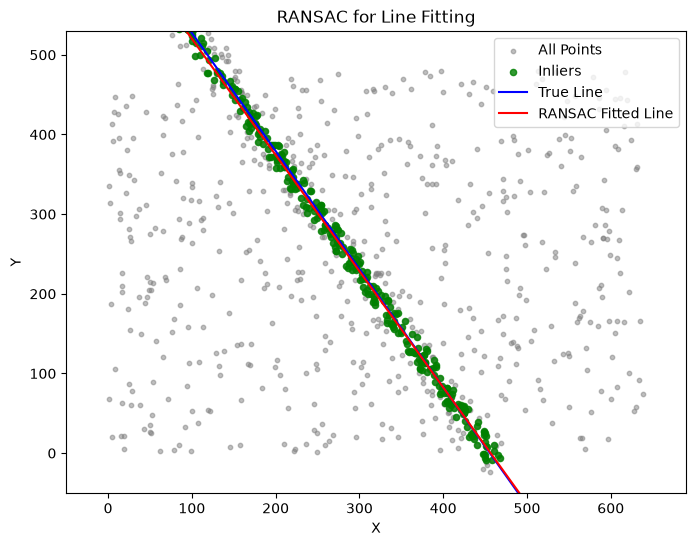

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(points[:,0], points[:,1], s=10, c='gray', alpha=0.5, label='All Points')
ax.scatter(inliers[:,0], inliers[:,1], s=20, c='green', alpha=0.8, label='Inliers')

p1 = (p[0] - 1000*dir_[0], p[1] - 1000*dir_[1])
p2 = (p[0] + 1000*dir_[0], p[1] + 1000*dir_[1])
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], c='blue', label='True Line')

a, b, c = best_line
x_vals = np.linspace(0, 640, 2)
y_vals = (-a*x_vals - c) / b
ax.plot(x_vals, y_vals, c='red', label='RANSAC Fitted Line')

ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('RANSAC for Line Fitting')
ax.legend()
plt.show()


## 6. Conclusion
We successfully demonstrated how **RANSAC** can robustly fit a line even with 50% outliers.
